# Spruce Budworm Model — Level II Parameters (with $T_E$)
Generated with Claude, corrected and verified by Zhiming Kuang (June 28, 2026).  
Ludwig, Jones & Holling (1978) — extended formulation

**State variables:**
- $B$ — budworm density (larvae/acre)
- $S$ — branch density (branches/acre)
- $E$ — foliage energy (dimensionless, 0–1)

**Equations:**
$$\frac{dB}{dt} = r_B B\left(1 - \frac{B}{K'S}\cdot\frac{T_E^2 + E^2}{E^2}\right) - \beta\frac{B^2}{(\alpha' S)^2 + B^2}$$
$$\frac{dS}{dt} = r_S S\left(1 - \frac{S\,K_E}{E\,K_S}\right)$$
$$\frac{dE}{dt} = r_E E\left(1 - \frac{E}{K_E}\right) - P'\frac{B}{S}\cdot\frac{E^2}{T_E^2 + E^2}$$

In [3]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

In [4]:
# Parameters (Level II)
r_B   = 1.6      # intrinsic budworm growth rate       (1/year)
K_B   = 200      # max budworm density                 (larvae/branch)  [range: 100–300]
beta  = 28000    # max budworm predation rate          (larvae/acre/year) [range: 20000–36000]
alpha = 1.5      # half-max density for predation      (larvae/branch)  [range: 1–2]
r_S   = 0.15     # intrinsic branch growth rate        (1/year)
K_S   = 24000    # max branch density                  (branches/acre)
K_E   = 1.0      # max E level                         (dimensionless)
r_E   = 1.0      # intrinsic E growth rate             (1/year)
P     = 0.0015   # consumption rate of E               (1/larvae)
T_E   = 0.01     # E threshold parameter               (dimensionless)

In [5]:
def budworm_rhs(t, y):
    B, S, E = y
    dB = r_B * B * (1 - (B / (K_B * S)) * (T_E**2 + E**2) / E**2) \
         - beta * B**2 / ((alpha * S)**2 + B**2)
    dS = r_S * S * (1 - (S * K_E) / (E * K_S))
    dE = r_E * E * (1 - E / K_E) - P * (B / S) * E**2 / (T_E**2 + E**2)
    return [dB, dS, dE]

In [6]:
# Initial conditions and time span
y0     = [200, 20000, 0.5]
tspan  = (0, 150)
t_eval = np.linspace(*tspan, 1500)

sol = solve_ivp(budworm_rhs, tspan, y0, t_eval=t_eval, method='RK45', rtol=1e-8, atol=1e-10)

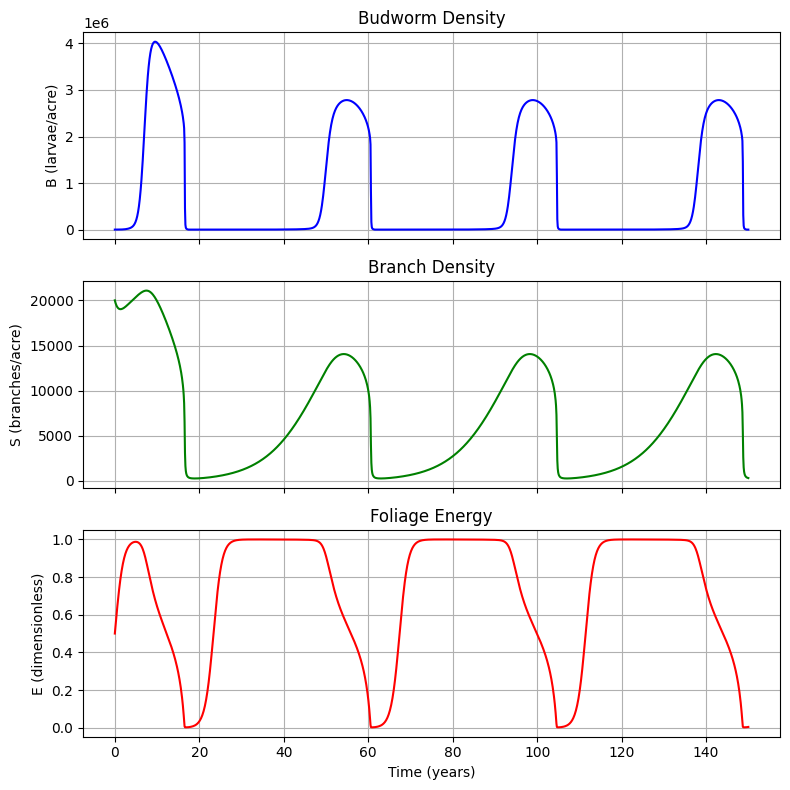

In [7]:
fig, axes = plt.subplots(3, 1, figsize=(8, 8), sharex=True)

axes[0].plot(sol.t, sol.y[0], 'b', linewidth=1.5)
axes[0].set_ylabel('B (larvae/acre)')
axes[0].set_title('Budworm Density')
axes[0].grid(True)

axes[1].plot(sol.t, sol.y[1], 'g', linewidth=1.5)
axes[1].set_ylabel('S (branches/acre)')
axes[1].set_title('Branch Density')
axes[1].grid(True)

axes[2].plot(sol.t, sol.y[2], 'r', linewidth=1.5)
axes[2].set_ylabel('E (dimensionless)')
axes[2].set_title('Foliage Energy')
axes[2].set_xlabel('Time (years)')
axes[2].grid(True)

plt.tight_layout()
plt.show()